In [1]:
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
data = simulate_cells(G = 2000, N = 5000, dispersion = 1, alpha = 0.01, beta = 0.03)
print(data)

AnnData object with n_obs × n_vars = 5000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size'
    var: 'ambient_profile', 'is_marker'
    uns: 'simulation_params', 'marker_sets', 'type_profiles'
    layers: 'noise', 'real'


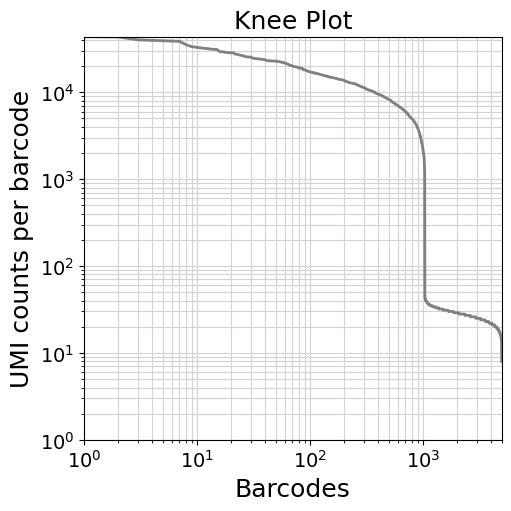

In [3]:
cm_utils.knee_plot(data)

In [ ]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.03, eps=1e-9, cell_ambient_fraction=0.01, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path)

11:45:52 - INFO - Added 'ambient_fraction' to adata.var.
11:45:52 - INFO - Inferring celltype profiles.


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


11:45:52 - INFO - EM Iter   1: ll=-68167150.404 beta=0.021658
11:45:52 - INFO - EM Iter   2: ll=-70238680.647 beta=0.020397
11:45:52 - INFO - EM Iter   3: ll=-70199840.535 beta=0.019529
11:45:53 - INFO - EM Iter   4: ll=-70183488.407 beta=0.018819
11:45:53 - INFO - EM Iter   5: ll=-70174186.479 beta=0.018194
11:45:53 - INFO - EM Iter   6: ll=-70168336.034 beta=0.017626
11:45:54 - INFO - EM Iter   7: ll=-70164500.638 beta=0.017104
11:45:54 - INFO - EM Iter   8: ll=-70161905.135 beta=0.016618
11:45:54 - INFO - EM Iter   9: ll=-70160081.189 beta=0.016164
11:45:54 - INFO - EM Iter  10: ll=-70158740.411 beta=0.015737
11:45:55 - INFO - EM Iter  11: ll=-70157706.827 beta=0.015332
11:45:55 - INFO - EM Iter  12: ll=-70156874.066 beta=0.014947
11:45:55 - INFO - EM Iter  13: ll=-70156177.860 beta=0.014579
11:45:55 - INFO - EM Iter  14: ll=-70155578.938 beta=0.014227
11:45:56 - INFO - EM Iter  15: ll=-70155052.743 beta=0.013889
11:45:56 - INFO - EM Iter  16: ll=-70154583.397 beta=0.013563
11:45:56

In [5]:
data.obs
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction']+1)

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


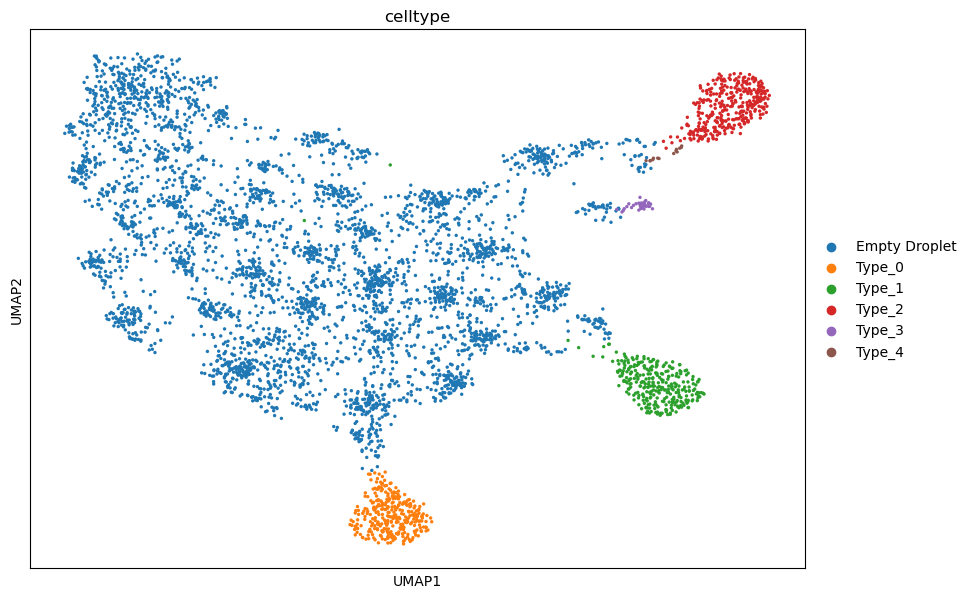

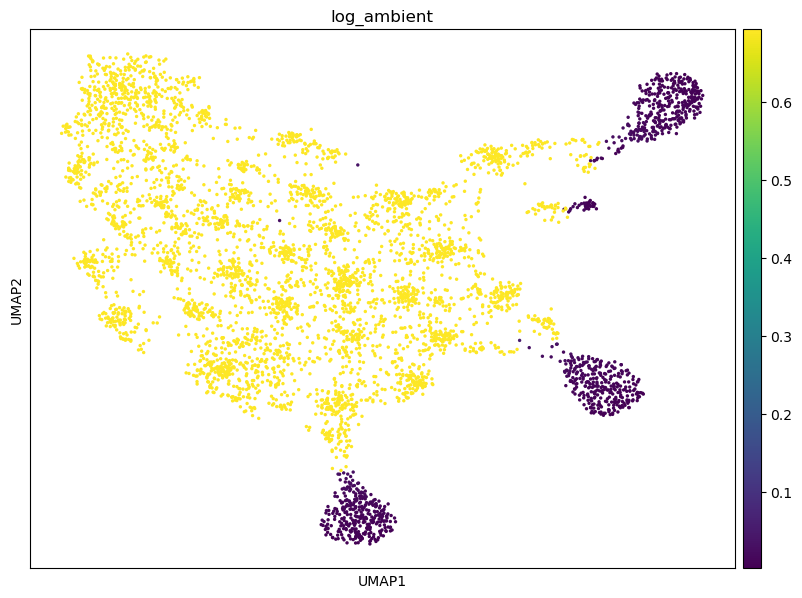

In [6]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='log_ambient', ax=ax)

In [7]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_18         3   Type_2     False          0.006773  16148.779264   
Cell_19         3   Type_2     False          0.012412   6659.428810   
Cell_30         2   Type_1     False          0.028817   4013.363489   
Cell_31         3   Type_2     False          0.015187   6222.906934   
Cell_34         2   Type_1     False          0.010126   8550.956138   
...           ...      ...       ...               ...           ...   
Cell_4970       3   Type_2     False          0.015459   5603.595453   
Cell_4981       3   Type_2     False          0.017208   5386.356493   
Cell_4984       1   Type_0     False          0.009355  11245.953064   
Cell_4987       1   Type_0     False          0.010745   9517.929380   
Cell_4989       1   Type_0     False          0.012656   7182.168753   

           cell_ambient_fraction  alpha_hat  z_hat  
Cell_18                     0.01   0.054633      3  
Cell_19                     0

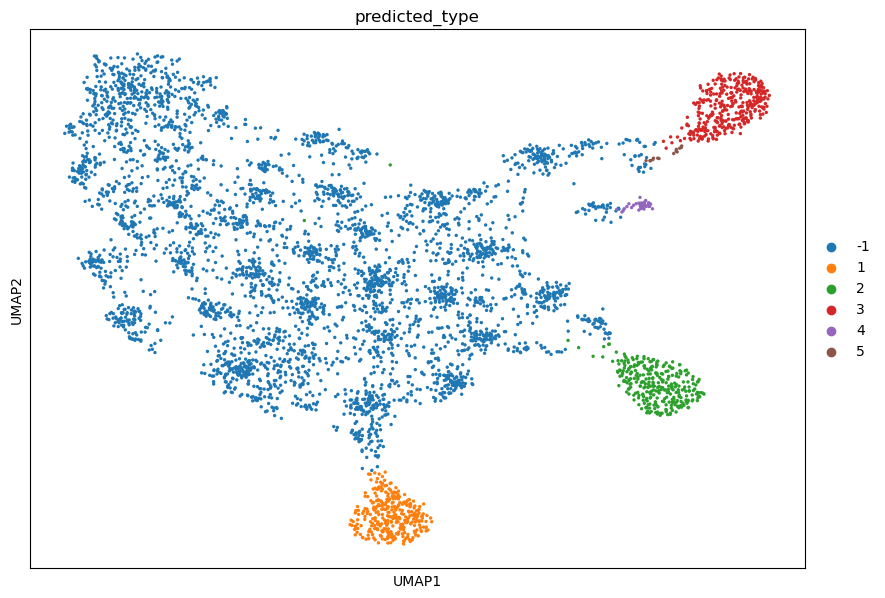

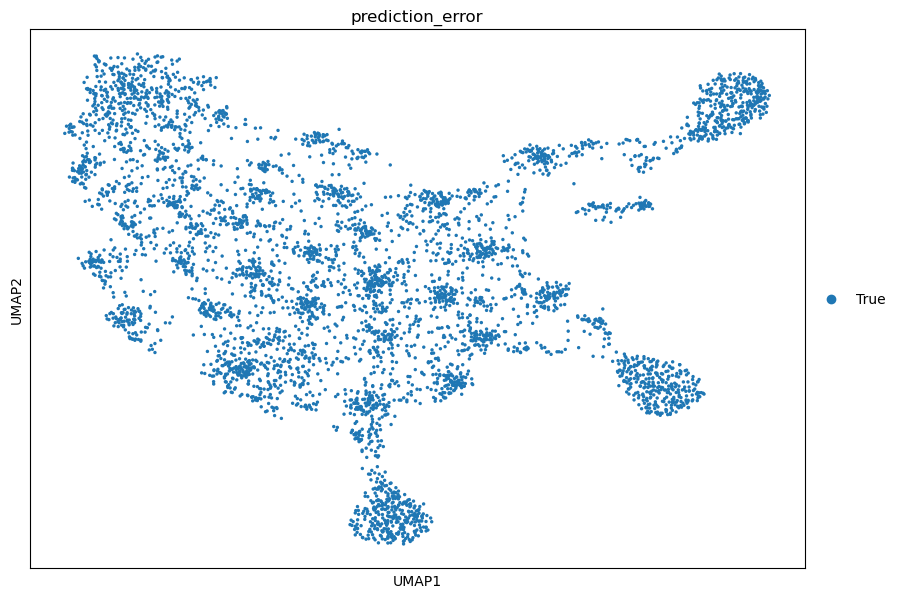

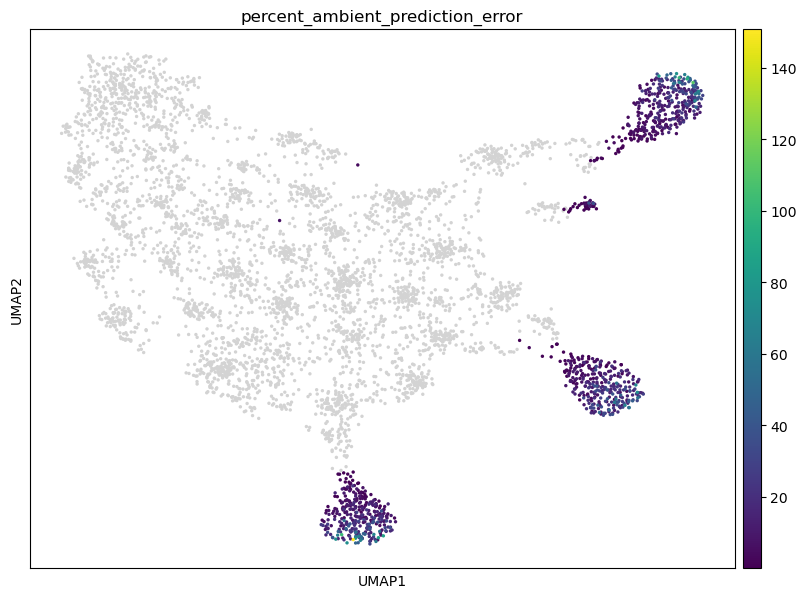

In [8]:
data.obs['percent_ambient_prediction_error'] = (np.abs(data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat']))/(np.abs(denoised_data.obs['ambient_fraction']))
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)